In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/credits.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/keywords.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links.csv


# 🎬 Multi-Stage Movie Recommendation Engine
### From Simple Heuristics to Metadata-Rich Content Filtering
**Project Scope:** 
1. **Base Recommender:** IMDB Weighted Rating.
2. **Content-Based (Overview):** NLP on Plot Summaries.
3. **Content-Based (Metadata):** Feature "Soup" (Director, Cast, Keywords).


## 1. Imports & Dependencies

In [2]:
# Core data & math
import pandas as pd
import numpy as np
import ast
import gc
import sys
import re
import string
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn — text & similarity
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity

# NLTK — text preprocessing
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

## 2. Data Loading

In [3]:
# # Load Movies Metadata
imdb_data_dir = '/kaggle/input/datasets/rounakbanik/the-movies-dataset/'

In [4]:
# Reload fresh copies
metadata = pd.read_csv(imdb_data_dir + 'movies_metadata.csv')
credits = pd.read_csv(imdb_data_dir + 'credits.csv')
keywords = pd.read_csv(imdb_data_dir + 'keywords.csv')

/tmp/ipykernel_55/3239268092.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(imdb_data_dir + 'movies_metadata.csv')


In [5]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


## 3. Data Cleaning & Deduplication

In [6]:
row1 = metadata.loc[19730]
row2 = metadata.loc[29503]
row3 = metadata.loc[35587]

print("="*50)
print(row1.to_string())
print("="*50)
print(row2.to_string())
print("="*50)
print(row3.to_string())

adult                                                   - Written by Ørnås
belongs_to_collection                                             0.065736
budget                                    /ff9qCepilowshEtG2GYWwzt2bs4.jpg
genres                   [{'name': 'Carousel Productions', 'id': 11176}...
homepage                 [{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso...
id                                                              1997-08-20
imdb_id                                                                  0
original_language                                                    104.0
original_title                    [{'iso_639_1': 'en', 'name': 'English'}]
overview                                                          Released
popularity                                                             NaN
poster_path                                                   Midnight Man
production_companies                                                 False
production_countries     

### 3.1 Remove Corrupted Rows from Metadata

In [7]:
metadata = metadata.drop([19730, 29503, 35587], errors='ignore')

In [8]:
metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce')
credits['id'] = pd.to_numeric(credits['id'], errors='coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors='coerce')

### 3.2 Null Value Check Across All Datasets

In [9]:
null_count = metadata['id'].isnull().sum()
print(f"Total null values: {null_count}")
print("="*50)
null_count = credits['id'].isnull().sum()
print(f"Total null values: {null_count}")
print("="*50)
null_count = keywords['id'].isnull().sum()
print(f"Total null values: {null_count}")

Total null values: 0
Total null values: 0
Total null values: 0


### 3.3 Duplicate Analysis & Visualisation — Before

In [10]:
def duplicate_report(df, name):
    print("="*50)
    print(f"DUPLICATE REPORT: {name}")
    print("="*50)

    total_rows = len(df)
    unique_ids = df['id'].nunique()
    duplicate_ids = total_rows - unique_ids
    full_duplicates = df.duplicated().sum()

    print(f"Total rows: {total_rows}")
    print(f"Unique IDs: {unique_ids}")
    print(f"Duplicate ID rows: {duplicate_ids}")
    print(f"Fully identical duplicate rows: {full_duplicates}")

    return total_rows, unique_ids, duplicate_ids

In [11]:
meta_stats = duplicate_report(metadata, "METADATA")
cred_stats = duplicate_report(credits, "CREDITS")
key_stats = duplicate_report(keywords, "KEYWORDS")

DUPLICATE REPORT: METADATA
Total rows: 45463
Unique IDs: 45433
Duplicate ID rows: 30
Fully identical duplicate rows: 13
DUPLICATE REPORT: CREDITS
Total rows: 45476
Unique IDs: 45432
Duplicate ID rows: 44
Fully identical duplicate rows: 37
DUPLICATE REPORT: KEYWORDS
Total rows: 46419
Unique IDs: 45432
Duplicate ID rows: 987
Fully identical duplicate rows: 987


In [12]:
def plot_duplicates(stats_list, labels, title):
    counts = [s[2] for s in stats_list]
    plt.figure()
    plt.bar(labels, counts)
    plt.title(title)
    plt.xlabel("Dataset")
    plt.ylabel("Number of Duplicate Rows")
    plt.show()

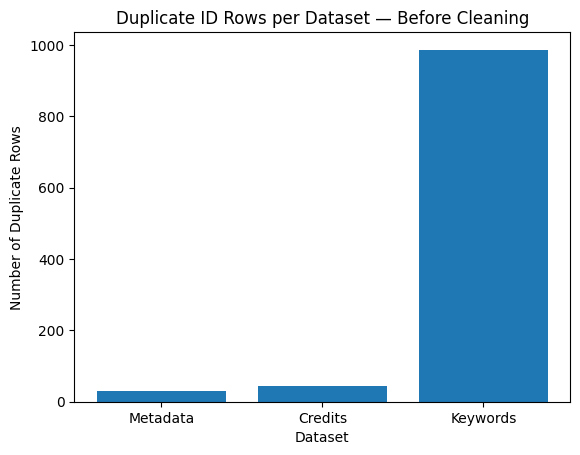

In [13]:
plot_duplicates(
    [meta_stats, cred_stats, key_stats],
    ['Metadata', 'Credits', 'Keywords'],
    "Duplicate ID Rows per Dataset — Before Cleaning"
)

In [14]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [15]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45463 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  object 
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  object 
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45460 non-null  object 
 11  poster_path            45077 non-null  object 
 12  production_companies   45460 non-null  object 
 13  production_countries   45460 non-null  object 
 14  release_date           45376 non-null  object 
 15  revenue

### 3.4 Resolve Duplicates Using Quality Scoring

In [16]:
# Convert numeric columns safely
numeric_cols = ['vote_count', 'vote_average', 'popularity', 'revenue', 'budget', 'runtime']

for col in numeric_cols:
    metadata[col] = pd.to_numeric(metadata[col], errors='coerce').fillna(0)

# indicators
metadata['has_overview'] = metadata['overview'].notna().astype(int)
metadata['has_tagline'] = metadata['tagline'].notna().astype(int)
metadata['has_homepage'] = metadata['homepage'].notna().astype(int)
metadata['has_genres'] = metadata['genres'].notna().astype(int)
metadata['has_production_companies'] = metadata['production_companies'].notna().astype(int)
metadata['has_spoken_languages'] = metadata['spoken_languages'].notna().astype(int)

# Overview length (longer descriptions are better)
metadata['overview_length'] = metadata['overview'].fillna('').apply(len)

# Normalize important numeric columns

def normalize(S):
    if S.max() == 0:
        return S
    return S / S.max()

metadata['vote_count_norm'] = normalize(metadata['vote_count'])
metadata['popularity_norm'] = normalize(metadata['popularity'])
metadata['revenue_norm'] = normalize(metadata['revenue'])
metadata['budget_norm'] = normalize(metadata['budget'])
metadata['runtime_norm'] = normalize(metadata['runtime'])
metadata['overview_length_norm'] = normalize(metadata['overview_length'])

# Create composite quality score

metadata['quality_score'] = (
      metadata['vote_count_norm'] * 2
    + metadata['popularity_norm'] * 1.5
    + metadata['revenue_norm']
    + metadata['budget_norm']
    + metadata['runtime_norm']
    + metadata['overview_length_norm']
    + metadata['has_overview']
    + metadata['has_tagline']
    + metadata['has_homepage']
    + metadata['has_genres']
    + metadata['has_production_companies']
    + metadata['has_spoken_languages']
)

In [17]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,has_production_companies,has_spoken_languages,overview_length,vote_count_norm,popularity_norm,revenue_norm,budget_norm,runtime_norm,overview_length_norm,quality_score
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1,1,303,0.384725,0.040087,0.133988,0.078947,0.064490,0.303,6.410005
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1,1,395,0.171439,0.031079,0.094261,0.171053,0.082803,0.395,6.132613
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1,1,327,0.006536,0.021394,0.000000,0.000000,0.080414,0.327,5.452578
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1,1,270,0.002416,0.007049,0.029216,0.042105,0.101115,0.270,5.457841
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1,1,318,0.012291,0.015320,0.027468,0.000000,0.084395,0.318,5.477425


In [18]:
# Keep best version per movie
metadata = metadata.sort_values('quality_score', ascending=False)
metadata = metadata.drop_duplicates(subset='id', keep='first')

In [19]:
# Clean helper columns
helper_cols = [col for col in metadata.columns if 
               'norm' in col or 
               col.startswith('has_') or 
               col == 'quality_score' or 
               col == 'overview_length']

metadata = metadata.drop(columns=helper_cols)

In [20]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
14551,False,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",http://www.avatarmovie.com/,19995,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",...,2009-12-10,2.787965e+09,162.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Enter the World of Pandora.,Avatar,False,7.2,12114.0
17818,False,"{'id': 86311, 'name': 'The Avengers Collection...",220000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",http://marvel.com/avengers_movie/,24428,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,...,2012-04-25,1.519558e+09,143.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Some assembly required.,The Avengers,False,7.4,12000.0
12481,False,"{'id': 263, 'name': 'The Dark Knight Collectio...",185000000,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...",http://thedarkknight.warnerbros.com/dvdsite/,155,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,...,2008-07-16,1.004558e+09,152.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Why So Serious?,The Dark Knight,False,8.3,12269.0
1639,False,NaN,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",http://www.titanicmovie.com,597,tt0120338,en,Titanic,"84 years later, a 101-year-old woman named Ros...",...,1997-11-18,1.845034e+09,194.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Nothing on Earth could come between them.,Titanic,False,7.5,7770.0
15480,False,NaN,160000000,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",http://inceptionmovie.warnerbros.com/,27205,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",...,2010-07-14,8.255328e+08,148.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Your mind is the scene of the crime.,Inception,False,8.1,14075.0


In [21]:
def get_list_size(x):
    try:
        return len(ast.literal_eval(x))
    except:
        return 0

credits['cast_size'] = credits['cast'].apply(get_list_size)
credits['crew_size'] = credits['crew'].apply(get_list_size)

credits['total_people'] = credits['cast_size'] + credits['crew_size']

In [22]:
credits = credits.sort_values('total_people', ascending=False)

credits = credits.drop_duplicates(subset='id', keep='first')

In [23]:
credits = credits.drop(columns=['cast_size', 'crew_size', 'total_people'])

In [24]:
# Drop exact duplicates based on id
keywords = keywords.drop_duplicates(subset='id', keep='first')

In [25]:
# Count duplicate IDs after cleaning
meta_stats_after = duplicate_report(metadata, "METADATA")
cred_stats_after = duplicate_report(credits, "CREDITS")
key_stats_after = duplicate_report(keywords, "KEYWORDS")

DUPLICATE REPORT: METADATA
Total rows: 45433
Unique IDs: 45433
Duplicate ID rows: 0
Fully identical duplicate rows: 0
DUPLICATE REPORT: CREDITS
Total rows: 45432
Unique IDs: 45432
Duplicate ID rows: 0
Fully identical duplicate rows: 0
DUPLICATE REPORT: KEYWORDS
Total rows: 45432
Unique IDs: 45432
Duplicate ID rows: 0
Fully identical duplicate rows: 0


### 3.5 Duplicate Analysis & Visualisation — After

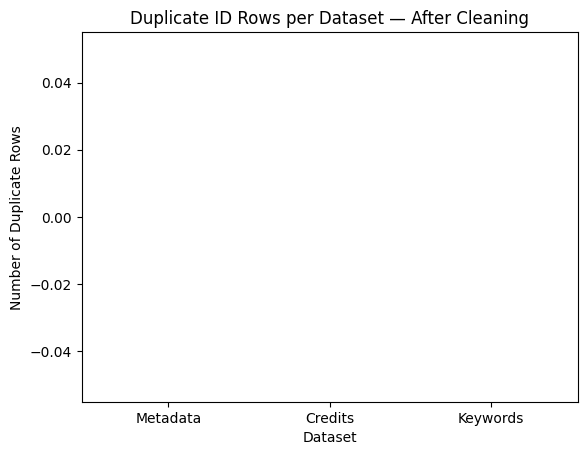

In [26]:
plot_duplicates(
    [meta_stats_after, cred_stats_after, key_stats_after],
    ['Metadata', 'Credits', 'Keywords'],
    "Duplicate ID Rows per Dataset — After Cleaning"
)
 

In [27]:
metadata = metadata.reset_index(drop=True)
keywords = keywords.reset_index(drop=True)
credits = credits.reset_index(drop=True)

## 4. Demographic Filtering — Top Rated Movies
#### IMDB Weighted Rating Formula: score = (v/(v+m) × R) + (m/(m+v) × C)
- **C** — Mean vote across all movies.
- **M** — Minimum votes required (90th percentile).
- **v** — Vote count for the movie.
- **R** — Average rating for the movie.

In [28]:
# C: The mean vote across the whole report
C = metadata['vote_average'].mean()

# M: The minimum votes required to be listed in the chart (90th percentile)
M = metadata['vote_count'].quantile(0.90)

# 2. Filter qualified movies
qualified_movies = metadata[metadata['vote_count'] >= M].copy()

# 3. Formula
v = qualified_movies['vote_count']
R = qualified_movies['vote_average']

# Calculation based on the IMDB formula
qualified_movies['score'] = (v / (v + M) * R) + (M / (M + v) * C)

# 4. Sort and Display
qualified_movies = qualified_movies.sort_values('score', ascending=False)

# Show the top 15 results
print(f"Mean Vote (C): {C:.2f}")
print(f"Minimum Votes Required (M): {M:.0f}")
print(f"Qualified Movies: {qualified_movies.shape[0]}")

Mean Vote (C): 5.62
Minimum Votes Required (M): 160
Qualified Movies: 4551


In [29]:
print("--- Top 15 Highest Rated Movies (Global) ---")
print(qualified_movies[['title', 'vote_count', 'vote_average', 'score']].head(15))

--- Top 15 Highest Rated Movies (Global) ---
                                title  vote_count  vote_average     score
620          The Shawshank Redemption      8358.0           8.5  8.445864
149                     The Godfather      6024.0           8.5  8.425432
5826      Dilwale Dulhania Le Jayenge       661.0           9.1  8.421405
2                     The Dark Knight     12269.0           8.3  8.265474
46                         Fight Club      9678.0           8.3  8.256381
361                      Pulp Fiction      8670.0           8.3  8.251401
257                  Schindler's List      4436.0           8.3  8.206630
422                          Whiplash      4376.0           8.3  8.205395
279                     Spirited Away      3968.0           8.3  8.196045
4401                Life Is Beautiful      3643.0           8.3  8.187161
4757           The Godfather: Part II      3418.0           8.3  8.180065
5251  One Flew Over the Cuckoo's Nest      3001.0           8.3  8.

## 5. Content-Based Filtering — Overview (TF-IDF)

### 5.1 Build TF-IDF Matrix from Movie Overviews

In [30]:
#Define a TF-IDF Vectorizer 
tfidf = TfidfVectorizer(stop_words='english')

#Replace NaN with an empty string
metadata['overview'] = metadata['overview'].fillna('')

#Construct the required TF-IDF matrix by fitting and transforming the data
tfidf_matrix = tfidf.fit_transform(metadata['overview'])

#Output the shape of tfidf_matrix
tfidf_matrix.shape

(45433, 75827)

### 5.2 Compute Cosine Similarity

In [31]:
cosine_sim_Overviews = linear_kernel(tfidf_matrix, tfidf_matrix)

### 5.3 Recommendation Function & Example Output

In [32]:
def get_recommendations(title, cosine_sim_Overviews, indices):
    if title not in indices:
        return f"Movie title '{title}' not found in the database."
 
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
 
    sim_indices = np.argsort(cosine_sim_Overviews[idx])[::-1][1:11]
    return metadata['title'].iloc[sim_indices]

In [33]:
indices_tfidf = pd.Series(metadata.index, index=metadata['title']).drop_duplicates()
 
# print("Recommendations for 'The Shawshank Redemption' (TF-IDF) Overview:")
recommendations = get_recommendations('The Dark Knight Rises', cosine_sim_Overviews, indices_tfidf)

for i, movie in enumerate(recommendations, 1):
    print(f"{i}. {movie}")

1. The Dark Knight
2. Batman Forever
3. Batman Returns
4. Batman: Under the Red Hood
5. Batman
6. Batman Unmasked: The Psychology of the Dark Knight
7. Batman Beyond: Return of the Joker
8. Batman: Year One
9. Batman: The Dark Knight Returns, Part 1
10. Batman: Mask of the Phantasm


In [34]:
# # User Input Example
# target_film = input("Enter a movie title to get recommendations: ").strip()

# # Check if the film exists
# if target_film in indices_tfidf:
#     print(f"\nSince you liked '{target_film}', you might also enjoy:\n")
    
#     recommendations = get_recommendations(target_film , cosine_sim_Overviews, indices_tfidf)
    
#     for i, movie in enumerate(recommendations, 1):
#         print(f"{i}. {movie}")
# else:
#     print(f"\nSorry, '{target_film}' was not found in our database.")

### 5.4 Memory Cleanup — Delete cosine_sim Matrix

In [35]:
size_mb = sys.getsizeof(cosine_sim_Overviews) / (1024 ** 2)
print(f"cosine_sim_Overviews is using {size_mb:.2f} MB — freeing now.")
 
del cosine_sim_Overviews
gc.collect()
print("Memory cleared.")

cosine_sim_Overviews is using 15748.27 MB — freeing now.
Memory cleared.


## 6. Content-Based Filtering — Metadata Soup
#### Cast · Crew · Keywords · Genres

### 6.1 Merge Credits & Keywords into Metadata

In [36]:
# Merge keywords and credits into your main metadata dataframe
metadata = metadata.merge(credits, on='id')
metadata = metadata.merge(keywords, on='id')

### 6.2 Feature Extraction — Director, Top-3 Cast, Genres, Keywords

In [37]:
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    metadata[feature] = metadata[feature].apply(ast.literal_eval)

In [38]:
def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
    return np.nan

In [39]:
# Returns the list top 3 elements or entire list; whichever is more.
def get_top3(x):
    if isinstance(x, list):
        names = [i['name'] for i in x]
        #Check if more than 3 elements exist. If yes, return only first three. If no, return entire list.
        return names[:3]

    #Return empty list in case of missing/malformed data
    return []

In [40]:
# Function to convert all strings to lower case and strip names of spaces
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    if isinstance(x, str):
        return x.lower().replace(" ", "")
    return ''

### 6.3 Build "Soup" String & Count Vectorisation

In [41]:
# Define new director, cast, genres and keywords features that are in a suitable form.
metadata['director'] = metadata['crew'].apply(get_director)

features = ['cast', 'keywords', 'genres']
for feature in features:
    metadata[feature] = metadata[feature].apply(get_top3)

In [42]:
# Print the new features
metadata[['title', 'cast', 'director', 'keywords', 'genres']].head(10)

,title,cast,director,keywords,genres
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"[culture clash, future, space war]","[Action, Adventure, Fantasy]"
1,The Avengers,"[Robert Downey Jr., Chris Evans, Mark Ruffalo]",Joss Whedon,"[new york, shield, marvel comic]","[Science Fiction, Action, Adventure]"
2,The Dark Knight,"[Christian Bale, Michael Caine, Heath Ledger]",Christopher Nolan,"[dc comics, crime fighter, secret identity]","[Drama, Action, Crime]"
3,Titanic,"[Kate Winslet, Leonardo DiCaprio, Frances Fisher]",James Cameron,"[shipwreck, iceberg, ship]","[Drama, Romance, Thriller]"
4,Inception,"[Leonardo DiCaprio, Joseph Gordon-Levitt, Elle...",Christopher Nolan,"[loss of lover, dream, kidnapping]","[Action, Thriller, Science Fiction]"
5,Minions,"[Sandra Bullock, Jon Hamm, Michael Keaton]",Kyle Balda,"[assistant, aftercreditsstinger, duringcredits...","[Family, Animation, Adventure]"
6,Deadpool,"[Ryan Reynolds, Morena Baccarin, Ed Skrein]",Tim Miller,"[anti hero, mercenary, marvel comic]","[Action, Adventure, Comedy]"
7,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,"[dc comics, crime fighter, terrorist]","[Action, Crime, Drama]"
8,Captain America: Civil War,"[Chris Evans, Robert Downey Jr., Scarlett Joha...",Anthony Russo,"[civil war, war, marvel comic]","[Adventure, Action, Science Fiction]"
9,Star Wars: The Force Awakens,"[Daisy Ridley, John Boyega, Adam Driver]",J.J. Abrams,"[android, spaceship, jedi]","[Action, Adventure, Science Fiction]"


In [43]:
# Apply clean_data function to your features.
features = ['cast', 'keywords', 'director', 'genres']

for feature in features:
    metadata[feature] = metadata[feature].apply(clean_data)

In [44]:
def create_soup(x):
    return (
        ' '.join(x['keywords']) + ' ' +
        ' '.join(x['cast'])     + ' ' +
        x['director']           + ' ' +
        ' '.join(x['genres'])
    )

In [45]:
metadata['soup'] = metadata.apply(create_soup, axis=1)

In [46]:
count        = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(metadata['soup'])

### 6.4 Compute Cosine Similarity & Recommendation Function

In [47]:
# size_mb = sys.getsizeof(cosine_sim_soup) / (1024 ** 2)
# print(f"cosine_sim_Overviews is using {size_mb:.2f} MB — freeing now.")
 
# del cosine_sim_soup
# gc.collect()
# print("Memory cleared.")

In [48]:
cosine_sim_soup = cosine_similarity(count_matrix, count_matrix)
 
metadata = metadata.reset_index()
indices_soup = pd.Series(metadata.index, index=metadata['title']).drop_duplicates()

In [49]:
recommendations = get_recommendations('The Godfather', cosine_sim_soup, indices_soup)

for i, movie in enumerate(recommendations, 1):
    print(f"{i}. {movie}")

1. The Godfather: Part III
2. The Godfather: Part II
3. The Rain People
4. Rege
5. Last Exit
6. Manuscripts Don't Burn
7. The Good Neighbor
8. In the Name of the Law
9. The Night of the Following Day
10. The Son of No One


In [50]:
# # User Input Example
# target_film = input("Enter a movie title to get recommendations: ").strip()

# # Check if the film exists
# if target_film in indices_soup:
#     print(f"\nSince you liked '{target_film}', you might also enjoy:\n")
    
#     recommendations = get_recommendations(target_film , cosine_sim_soup, indices_soup)
    
#     for i, movie in enumerate(recommendations, 1):
#         print(f"{i}. {movie}")
# else:
#     print(f"\nSorry, '{target_film}' was not found in our database.")